In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from torch.optim import LBFGS, Adam
from tqdm import tqdm
import scipy.io
import os
import sys
current_dir = os.path.abspath('')
grandparent_dir = os.path.dirname(os.path.dirname(current_dir))
if grandparent_dir not in sys.path:
    sys.path.append(grandparent_dir)

from util import (
    get_n_params,
    get_pseudo_spacetime_cross_center_index,
    make_pseudo_spacetime_cross_offsets,
    ModelTimeRecorder,
    RelativeL2ConvergenceTracker,
)
from model.CaPITN import CaPITN

if not os.path.exists('results'):
    os.makedirs('results')

In [2]:
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_space = 3
space_step = 1e-2
num_step = 5
step_size = 1e-4

space_dim = 2
num_spatial_tokens = 1 + space_dim * (num_space - 1)
spatial_radius = (num_space // 2) * space_step
c_max = spatial_radius / step_size
center_index = get_pseudo_spacetime_cross_center_index(
    space_dim,
    num_space=num_space,
    num_step=num_step,
)

patch_offsets = torch.tensor(
    make_pseudo_spacetime_cross_offsets(
        space_dim,
        num_space=num_space,
        space_step=space_step,
        num_step=num_step,
        step=step_size,
    ),
    dtype=torch.float32,
    device=device,
)
assert patch_offsets.shape == (
    num_step * num_spatial_tokens,
    space_dim + 1,
)
assert torch.equal(
    patch_offsets[center_index],
    torch.zeros(space_dim + 1, dtype=torch.float32, device=device),
)

In [3]:
data = scipy.io.loadmat('./cylinder_nektar_wake.mat')

In [4]:
U_star = data['U_star']
P_star = data['p_star']
t_star = data['t']
X_star = data['X_star']

N = X_star.shape[0]
T = t_star.shape[0]

XX = np.tile(X_star[:, 0:1], (1, T))
YY = np.tile(X_star[:, 1:2], (1, T))
TT = np.tile(t_star, (1, N)).T

UU = U_star[:, 0, :]
VV = U_star[:, 1, :]
PP = P_star

x = XX.flatten()[:, None]
y = YY.flatten()[:, None]
t = TT.flatten()[:, None]

u = UU.flatten()[:, None]
v = VV.flatten()[:, None]
p = PP.flatten()[:, None]


def build_patch(src):
    src = np.asarray(src)
    assert src.ndim == 2 and src.shape[1] == 3
    center = torch.as_tensor(src, dtype=torch.float32, device=device).unsqueeze(1)
    assert center.shape == (src.shape[0], 1, 3)
    torch.testing.assert_close(
        center[:, 0, :],
        torch.as_tensor(src, dtype=torch.float32, device=device),
    )
    return center


idx = np.random.choice(N * T, 2500, replace=False)
train_coords = np.concatenate([x[idx, :], y[idx, :], t[idx, :]], axis=-1)
u_train = u[idx, :]
v_train = v[idx, :]
p_train = p[idx, :]

train_center = build_patch(train_coords)

x_train = train_center[:, :, 0:1].requires_grad_(True)
y_train = train_center[:, :, 1:2].requires_grad_(True)
t_train = train_center[:, :, 2:3].requires_grad_(True)
assert x_train.shape == y_train.shape == t_train.shape == (train_coords.shape[0], 1, 1)
u_train = torch.tensor(u_train, dtype=torch.float32, device=device)
v_train = torch.tensor(v_train, dtype=torch.float32, device=device)
p_train = torch.tensor(p_train, dtype=torch.float32, device=device)

In [5]:
def rigid_patch_grad(value, coordinate_patch):
    token_grad = torch.autograd.grad(
        value,
        coordinate_patch,
        grad_outputs=torch.ones_like(value),
        retain_graph=True,
        create_graph=True,
    )[0]
    return token_grad.sum(dim=1)


def velocity_from_streamfunction(psi, x_patch, y_patch):
    u = rigid_patch_grad(psi, y_patch)
    v = -rigid_patch_grad(psi, x_patch)
    return u, v


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0.01)

In [6]:
model = CaPITN(
    in_dim=3,
    d_model=32,
    n_heads=2,
    d_ff=512,
    n_layers=1,
    out_dim=2,
    c_max=c_max,
).to(device)
model.apply(init_weights)
trainable_parameters = tuple(p for p in model.parameters() if p.requires_grad)
optim = LBFGS(trainable_parameters, line_search_fn='strong_wolfe')

print(model)
print(get_n_params(model))

CaPITN(
  (embedding): Linear(in_features=3, out_features=32, bias=True)
  (encoder): Encoder(
    (layers): ModuleList(
      (0): EncoderLayer(
        (attn): CharacteristicAwareAttention(
          (W_q): Linear(in_features=32, out_features=32, bias=True)
          (W_k): Linear(in_features=32, out_features=32, bias=True)
          (W_v): Linear(in_features=32, out_features=32, bias=True)
          (W_o): Linear(in_features=32, out_features=32, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (ffn): Sequential(
          (0): Linear(in_features=32, out_features=256, bias=True)
          (1): WaveBiasAct()
          (2): Linear(in_features=256, out_features=32, bias=True)
        )
      )
    )
  )
  (decoder): Decoder(
    (layers): ModuleList(
      (0): DecoderLayer(
        (attn): CharacteristicAwareAttention(
          (W_q): Linear(in_features=32, out_features=32, bias=True)
          (W_k): Linear(in_features=32, out_features=32, bias=True)
  

In [7]:
monitor_snap = 100
monitor_x_base = X_star[:, 0:1]
monitor_y_base = X_star[:, 1:2]
monitor_t_base = TT[:, monitor_snap].reshape(-1, 1)
monitor_reference = P_star[:, monitor_snap].reshape(-1, 1)
relative_l2_threshold = 0.1
monitor_reference = monitor_reference

def get_monitor_prediction():
    monitor_coords = np.concatenate(
        [monitor_x_base, monitor_y_base, monitor_t_base],
        axis=-1,
    )
    monitor_center = build_patch(monitor_coords)
    monitor_x = monitor_center[:, :, 0:1].clone().detach().requires_grad_(True)
    monitor_y = monitor_center[:, :, 1:2].clone().detach().requires_grad_(True)
    monitor_t = monitor_center[:, :, 2:3].clone().detach().requires_grad_(True)
    monitor_xy = torch.cat([monitor_x, monitor_y], dim=-1)
    prediction = model(monitor_xy, monitor_t, patch_offsets)[:, 0, 1:2]
    return prediction.detach().cpu().numpy().reshape(-1, 1)

convergence_tracker = RelativeL2ConvergenceTracker(
    monitor_reference,
    relative_l2_threshold,
)
convergence_tracker.record(0.0, get_monitor_prediction())


5.353078023977348

In [ ]:
time_recorder = ModelTimeRecorder(device)
loss_track = []

for i in tqdm(range(1000)):
    def closure():
        optim.zero_grad(set_to_none=True)

        xy_train = torch.cat([x_train, y_train], dim=-1)
        psi_and_p = model(xy_train, t_train, patch_offsets)
        psi = psi_and_p[:, 0, 0:1]
        p_pred = psi_and_p[:, 0, 1:2]

        u_pred, v_pred = velocity_from_streamfunction(psi, x_train, y_train)

        u_t = rigid_patch_grad(u_pred, t_train)
        u_x = rigid_patch_grad(u_pred, x_train)
        u_y = rigid_patch_grad(u_pred, y_train)
        u_xx = rigid_patch_grad(u_x, x_train)
        u_yy = rigid_patch_grad(u_y, y_train)

        v_t = rigid_patch_grad(v_pred, t_train)
        v_x = rigid_patch_grad(v_pred, x_train)
        v_y = rigid_patch_grad(v_pred, y_train)
        v_xx = rigid_patch_grad(v_x, x_train)
        v_yy = rigid_patch_grad(v_y, y_train)

        p_x = rigid_patch_grad(p_pred, x_train)
        p_y = rigid_patch_grad(p_pred, y_train)

        f_u = u_t + u_pred * u_x + v_pred * u_y + p_x - 0.01 * (u_xx + u_yy)
        f_v = v_t + u_pred * v_x + v_pred * v_y + p_y - 0.01 * (v_xx + v_yy)

        loss = (
            torch.mean((u_pred - u_train) ** 2)
            + torch.mean((v_pred - v_train) ** 2)
            + torch.mean((p_pred - p_train) ** 2)
            + torch.mean(f_u ** 2)
            + torch.mean(f_v ** 2)
        )

        if not torch.isfinite(loss).item():
            raise FloatingPointError(f'Non-finite total loss: {loss.detach().item()}')

        loss_track.append(loss.item())

        loss.backward(inputs=trainable_parameters)
        return loss

    with time_recorder.record_training():
        optim.step(closure)

    convergence_tracker.record(
        time_recorder.training_time,
        get_monitor_prediction(),
    )

100%|██████████| 1000/1000 [57:21<00:00,  3.44s/it] 


In [9]:
np.save('./results/ns_loss_CaPITN.npy', loss_track)
torch.save(model.state_dict(), './results/ns_CaPITN.pt')

loss_track[-1]

print('Training Time: {:.2f} s'.format(time_recorder.training_time))

np.save(
    './results/ns_relative_l2_error_vs_training_time_CaPITN_p.npy',
    convergence_tracker.as_array(),
)
if convergence_tracker.first_threshold_time is None:
    print('Relative L2 threshold {:.3f} was not reached.'.format(relative_l2_threshold))
else:
    print(
        'Relative L2 threshold {:.3f} first reached at {:.6f} s'.format(
            relative_l2_threshold,
            convergence_tracker.first_threshold_time,
        )
    )


Training Time: 3428.50 s
Relative L2 threshold 0.100 first reached at 191.192920 s


In [10]:
snap = np.array([100])
x_star_base = X_star[:, 0:1]
y_star_base = X_star[:, 1:2]
t_star_base = TT[:, snap]

u_star = U_star[:, 0, snap]
v_star = U_star[:, 1, snap]
p_star = P_star[:, snap]

test_coords = np.concatenate([x_star_base, y_star_base, t_star_base], axis=-1)
test_center = build_patch(test_coords)

x_star = test_center[:, :, 0:1].requires_grad_(True)
y_star = test_center[:, :, 1:2].requires_grad_(True)
t_star = test_center[:, :, 2:3].requires_grad_(True)
assert x_star.shape == y_star.shape == t_star.shape == (test_coords.shape[0], 1, 1)

In [11]:
with time_recorder.record_inference():
    xy_star = torch.cat([x_star, y_star], dim=-1)
    psi_and_p = model(xy_star, t_star, patch_offsets)
print('Inference Time: {:.6f} s'.format(time_recorder.inference_time))

psi = psi_and_p[:, 0, 0:1]
p_pred = psi_and_p[:, 0, 1:2]

u_pred, v_pred = velocity_from_streamfunction(psi, x_star, y_star)

u_pred = u_pred.cpu().detach().numpy()
v_pred = v_pred.cpu().detach().numpy()
p_pred = p_pred.cpu().detach().numpy()

error_u_l2 = np.linalg.norm(u_star - u_pred, 2) / np.linalg.norm(u_star, 2)
error_v_l2 = np.linalg.norm(v_star - v_pred, 2) / np.linalg.norm(v_star, 2)
error_p_l2 = np.linalg.norm(p_star - p_pred, 2) / np.linalg.norm(p_star, 2)

error_u_l2, error_v_l2, error_p_l2

Inference Time: 0.009688 s


(0.0017864167143106027, 0.005048822456014078, 0.009216902648731935)

In [12]:
error_u_l1 = np.linalg.norm(u_star-u_pred,1)/np.linalg.norm(u_star,1)
error_v_l1 = np.linalg.norm(v_star-v_pred,1)/np.linalg.norm(v_star,1)
error_p_l1 = np.linalg.norm(p_star-p_pred,1)/np.linalg.norm(p_star,1)

error_u_l1, error_v_l1, error_p_l1

(0.0011865214372214301, 0.0037435122005365163, 0.010973112434021038)

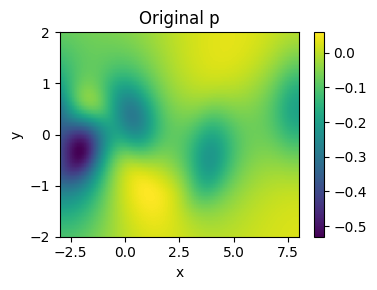

In [13]:
plt.figure(figsize=(4,3))
plt.imshow((p_star).reshape(50,100), extent=[-3,8,-2,2], aspect='auto')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Original p')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/ns_exact.png')
plt.show()

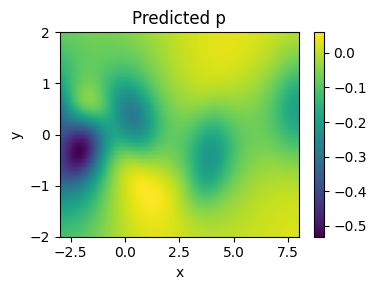

In [14]:
plt.figure(figsize=(4,3))
plt.imshow((p_pred).reshape(50,100), extent=[-3,8,-2,2], aspect='auto')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted p')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/ns_CaPITN_pred.png')
plt.show()

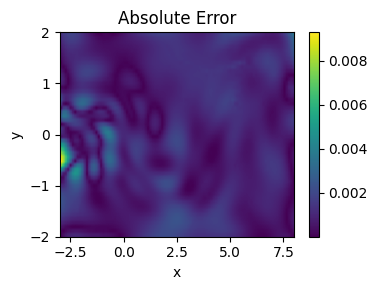

In [15]:
plt.figure(figsize=(4,3))
plt.imshow(np.abs(p_pred-p_star).reshape(50,100), extent=[-3,8,-2,2], aspect='auto')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Absolute Error')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/ns_CaPITN_error.png')
plt.show()